<a href="https://colab.research.google.com/github/ytang4456/0821-Pages-SUB/blob/mian/chengdu_weather2507.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 正在安装中文字体 (Noto Sans CJK) ---
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
--- 字体安装完成 ---
--- 正在清除 Matplotlib 字体缓存 ---
Matplotlib 缓存目录: /root/.cache/matplotlib
已删除缓存文件: /root/.cache/matplotlib/fontlist-v390.json
--- 字体管理器已强制重新加载 ---
Matplotlib 默认字体已设置为: ['Noto Sans CJK JP']

--- 请务必手动重启 Colab 运行时！ ---
在 Colab 菜单栏点击：`运行时 (Runtime)` > `重启会话 (Restart session)`。
重启后，**请务必从头运行所有代码单元格**。

--- 正在测试中文显示... ---


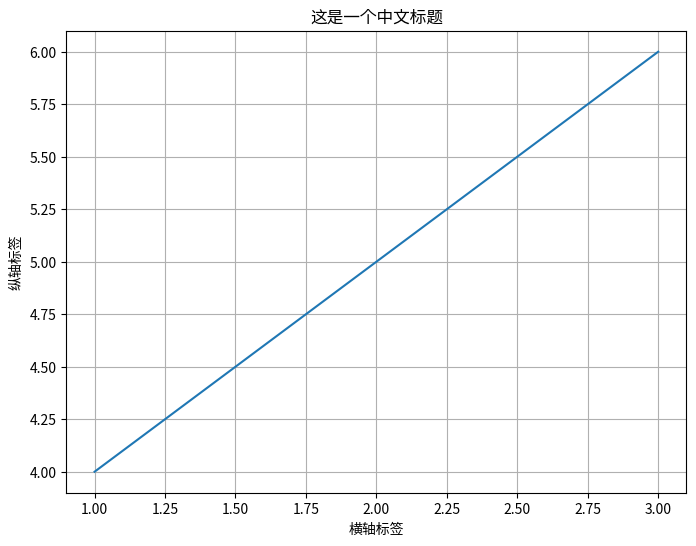


--- 字体配置完成，请检查图表是否正常显示中文。 ---
--- 如果仍有问题，请确保每一步都严格执行，特别是重启操作。 ---


In [ ]:
# --- 步骤 1: 安装中文字体 ---
# 这一步会下载并安装支持中文的字体，Colab 默认不支持中文显示
print("--- 正在安装中文字体 (Noto Sans CJK) ---")
!apt-get update > /dev/null # 更新包列表，不显示过多信息
!apt-get install -y fonts-noto-cjk > /dev/null # 安装 Noto Sans CJK 字体包
print("--- 字体安装完成 ---")

# --- 步骤 2: 清除 Matplotlib 字体缓存并重新加载 ---
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import shutil

print("--- 正在清除 Matplotlib 字体缓存 ---")
try:
    # 获取 Matplotlib 缓存目录 (新版本通常这样获取)
    import matplotlib
    matplotlib_cache_dir = matplotlib.get_cachedir()

    print(f"Matplotlib 缓存目录: {matplotlib_cache_dir}")

    # 遍历并删除所有 fontlist-*.json 缓存文件
    if os.path.exists(matplotlib_cache_dir):
        for filename in os.listdir(matplotlib_cache_dir):
            if filename.startswith('fontlist-') and filename.endswith('.json'):
                file_path = os.path.join(matplotlib_cache_dir, filename)
                try:
                    os.remove(file_path)
                    print(f"已删除缓存文件: {file_path}")
                except Exception as e:
                    print(f"删除缓存文件失败 {file_path}: {e}")
    else:
        print(f"Matplotlib 缓存目录不存在: {matplotlib_cache_dir}。无需清除。")
except Exception as e:
    print(f"获取或访问缓存目录时出错: {e}")

# 强制 Matplotlib 重新加载字体管理器
# 这一步非常关键，确保它重新扫描字体而不读取旧缓存
try:
    fm._load_fontmanager(try_read_cache=False)
    print("--- 字体管理器已强制重新加载 ---")
except Exception as e:
    print(f"强制重新加载字体管理器时出错: {e}。这通常不影响后续字体设置。")

# --- 步骤 3: 配置 Matplotlib 使用新字体 ---
# 我们选择 Noto Sans CJK JP 作为中文显示字体
font_preferred = 'Noto Sans CJK JP' # 你也可以尝试 'Noto Sans CJK SC' (简体中文)

# 设置 Matplotlib 的默认字体
plt.rcParams['font.family'] = font_preferred
# 解决负号显示为方块的问题 (可选，但推荐)
plt.rcParams['axes.unicode_minus'] = False

print(f"Matplotlib 默认字体已设置为: {plt.rcParams['font.family']}")

# --- 步骤 4: 重启运行时 (最最最重要的一步！) ---
# 这一步是让所有字体更改生效的关键。
print("\n--- 请务必手动重启 Colab 运行时！ ---")
print("在 Colab 菜单栏点击：`运行时 (Runtime)` > `重启会话 (Restart session)`。")
print("重启后，**请务必从头运行所有代码单元格**。")

# --- 步骤 5: 验证中文显示 (重启后再次运行此单元格) ---
# 在你重启 Colab 运行时，并从头运行了前面的代码后，运行下面这个测试
print("\n--- 正在测试中文显示... ---")
plt.figure(figsize=(8, 6))
plt.plot([1, 2, 3], [4, 5, 6])
plt.title('这是一个中文标题')
plt.xlabel('横轴标签')
plt.ylabel('纵轴标签')
plt.grid(True)
plt.show()

print("\n--- 字体配置完成，请检查图表是否正常显示中文。 ---")
print("--- 如果仍有问题，请确保每一步都严格执行，特别是重启操作。 ---")

In [ ]:
import pandas as pd
from google.colab import files

# --- 1. 上传你的 CSV 文件 ---
print("--- 正在等待您上传 CSV 文件 ---")
print("请点击下面的 '选择文件' 按钮，然后选择您电脑上的 CSV 文件。")

uploaded = files.upload() # 运行这行代码后，会弹出一个文件选择框

# 获取上传文件的文件名 (通常只有一个文件)
for fn in uploaded.keys():
  file_name = fn
  print(f"文件 '{file_name}' 已成功上传。")

# --- 2. 使用 Pandas 读取上传的 CSV 文件 ---
try:
  df = pd.read_csv(file_name)
  print(f"\n--- 文件 '{file_name}' 已成功加载到 DataFrame 中。---")

  # --- 3. 第一次查看数据 ---
  print("\n--- 数据集前5行：---")
  print(df.head())

  print("\n--- 数据集基本信息：---")
  df.info()

  print("\n--- 数据集统计描述：---")
  print(df.describe())

except Exception as e:
  print(f"\n--- 读取 CSV 文件时出错: {e} ---")
  print("请检查文件名是否正确，以及文件是否是有效的 CSV 格式。")
  print("如果文件包含中文且乱码，可能需要指定编码，例如：pd.read_csv(file_name, encoding='gbk')")

print("\n--- CSV 文件导入及初步分析完成 ---")

--- 正在等待您上传 CSV 文件 ---
请点击下面的 '选择文件' 按钮，然后选择您电脑上的 CSV 文件。


TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd

# 假设你的DataFrame叫做df，如果不是，请替换成你实际的DataFrame变量名
# df = pd.read_csv('你的文件名.csv') # 如果你还没有加载，请先加载你的CSV

print("--- 缺失值检测 ---")
# isnull() 或 isna() 会返回一个布尔型DataFrame，True 表示缺失值
# sum() 会统计每列的True数量，即缺失值的数量
missing_values = df.isnull().sum()
print(missing_values)

# 进一步查看缺失值占总体的百分比
print("\n--- 缺失值百分比 ---")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

# 筛选出有缺失值的列
columns_with_missing = missing_percentage[missing_percentage > 0]
if not columns_with_missing.empty:
    print(f"\n以下列包含缺失值：\n{columns_with_missing}")
else:
    print("\n数据集中没有缺失值！")

In [ ]:
import pandas as pd

# 假设你的DataFrame叫做df
# 如果你的DataFrame变量名不是df，请务必修改！
# 例如，如果你之前读取CSV后赋值给了my_data，那么这里就用my_data.dropna()

print("--- 正在删除包含任何缺失值的行 ---")

# 在执行删除操作前，先查看原始数据的行数
original_rows = df.shape[0]
print(f"原始数据行数: {original_rows}")

# 使用 .dropna() 方法删除包含缺失值的行
# inplace=True 会直接修改原始的 df DataFrame，而不是返回一个新的DataFrame
df.dropna(inplace=True)

# 再次查看处理后的数据行数
cleaned_rows = df.shape[0]
print(f"删除缺失值后的数据行数: {cleaned_rows}")
print(f"总共删除了 {original_rows - cleaned_rows} 行。")

print("\n--- 缺失值行删除完成 ---")

# 再次检查是否还有缺失值 (应该为0)
print("\n--- 再次检查缺失值 (所有列都应为0)：---")
print(df.isnull().sum())

# 你可以再次查看处理后的数据的前几行
# print("\n--- 删除缺失值行后的数据前5行：---")
# print(df.head())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files # 如果需要上传文件

# --- 1. 加载你的 CSV 文件 ---
# 运行此单元格时，会弹出文件选择框让你上传 chengdu_weather.csv
print("--- 请上传 chengdu_weather.csv 文件 ---")
uploaded = files.upload()
file_name = list(uploaded.keys())[0] # 获取上传的文件名
df = pd.read_csv(file_name) # 将你的数据读取到 df 中

print(f"文件 '{file_name}' 已加载。数据前5行：")
print(df.head())

# --- 2. 识别你的类别列和多个数值列 ---
# ================================================================
# 请根据你的 chengdu_weather.csv 文件，替换这里的占位符！！！
# ================================================================
category_column = 'time'  # <--- 请替换成你的实际【类别列名】 (例如: '月份', '天气状况' 等)
                          #      如果你想按日期分组，确保日期列是可用于分组的格式 (比如只有日期，没有时间)

numeric_columns = ['tmax', 'tmin', 'tavg'] # <--- 请替换成你的三个实际【数值列名】
                                                    #      例如: ['最高温度', '最低温度', '平均温度']
# ================================================================

# 检查这些列是否存在
missing_cols = [col for col in [category_column] + numeric_columns if col not in df.columns]
if missing_cols:
    print(f"\n错误：以下列在DataFrame中不存在，请检查列名是否正确：{missing_cols}")
    print("你的CSV文件可用列：", df.columns.tolist())
else:
    # --- 3. 对多个数值列计算每个类别的最大值、最小值、平均值 ---
    print(f"\n--- 正在计算按 '{category_column}' 分组的多个数值列统计值 ---")

    # 定义聚合字典，对每个数值列计算 max, min, mean
    agg_funcs = {}
    for col in numeric_columns:
        agg_funcs[f'{col}_最大值'] = (col, 'max')
        agg_funcs[f'{col}_最小值'] = (col, 'min')
        agg_funcs[f'{col}_平均值'] = (col, 'mean')

    summary_df = df.groupby(category_column).agg(**agg_funcs).reset_index()

    # 重命名列，让它们更清晰
    # 例如：'最高气温_最大值' 变成 '最高气温' (如果你的图例能区分就好了)
    # 或者我们保留它们，让图例更详细。这里先保留详细名称。

    print("\n--- 聚合后的数据框 ---")
    print(summary_df)

    # --- 4. 绘制分组柱状图 ---
    print("\n--- 正在绘制分组柱状图 ---")

    # melt() 转换数据为长格式
    # id_vars: 你的类别列，作为标识符
    # var_name: 新的列名，用来表示是哪个数值列的什么统计类型 (如 '最高气温_最大值')
    # value_name: 新的列名，包含实际的数值
    df_melted = summary_df.melt(id_vars=category_column,
                                var_name='统计类型',
                                value_name='数值')

    # 你可能想让图例更易读，可以尝试进一步处理 '统计类型' 列，比如：
    df_melted['数值列'] = df_melted['统计类型'].apply(lambda x: x.split('_')[0])
    df_melted['统计类型_精简'] = df_melted['统计类型'].apply(lambda x: x.split('_')[1])

    plt.figure(figsize=(15, 8)) # 增大图表尺寸，以容纳更多柱子

    # x: 你的类别列
    # y: 统计结果的数值
    # hue: 最外层分组（例如：最高气温、最低气温、平均气温）
    # col: 如果你想为每个类别（比如 '晴', '阴', '雨'）生成一个独立的子图，可以使用col=category_column
    #      这里我们想在一个图里显示所有柱子，所以不用col
    sns.barplot(x=category_column, y='数值', hue='统计类型', data=df_melted, palette='Paired')

    plt.title(f'按{category_column}划分的{", ".join(numeric_columns)}统计')
    plt.xlabel(category_column)
    plt.ylabel('数值 (例如：°C)') # 替换 (例如：°C) 为你的实际单位
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='统计类型')
    plt.xticks(rotation=45, ha='right') # 旋转X轴标签，特别是日期可能很长
    plt.tight_layout()
    plt.show()

    print("\n--- 分组柱状图绘制完成 ---")